# 데이터 시각화 (Data Visualization)

In [1]:
import numpy as np
import pandas as pd
import json
import re # 정규 표현식 사용
import matplotlib.pyplot as plt # 데이터 시각화
import seaborn as sns # Seaborn: 데이터 시각화 라이브러리
import scipy.stats as stats # 정규 분포 분석을 위한 SciPy

from matplotlib_venn import venn2

## 정형 데이터 (Structured Data)

### 1. 1번 미니 퀘스트
- 샘플 데이터프레임을 생성한 후, 데이터의 기본 정보를 출력하는 코드 작성

In [2]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)

# 데이터 프레임 기본 정보 확인
print(df.info(), "\n") # 기본 정보 출력
print(df.head(), "\n") # 상위 데이터 확인
print(df.describe(), "\n") # 통계 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      5 non-null      object
 1   나이      5 non-null      int64 
 2   직업      5 non-null      object
 3   연봉      5 non-null      int64 
 4   가입일     5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None 

    이름  나이    직업     연봉         가입일
0  김철수  25   개발자   4000  2020-05-21
1  이영희  30   마케터   3500  2019-07-15
2  박민수  35   개발자   5000  2021-01-10
3  최지현  28  디자이너   4200  2018-11-03
4  홍길동  40   CEO  10000  2017-09-27 

             나이           연봉
count   5.00000      5.00000
mean   31.60000   5340.00000
std     5.94138   2660.45109
min    25.00000   3500.00000
25%    28.00000   4000.00000
50%    30.00000   4200.00000
75%    35.00000   5000.00000
max    40.00000  10000.00000 



### 2. 2번 미니 퀘스트
- 샘플 데이터에서 나이가 30 이상이고 연봉이 5000 이하인 사람들만 필터링하는 코드 작성

In [3]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

# 조건 필터링
filtered = df[(df['나이'] >= 30) & (df['연봉'] <= 5000)]
print(filtered)

    이름  나이    직업    연봉         가입일
1  이영희  30   마케터  3500  2019-07-15
2  박민수  35   개발자  5000  2021-01-10
5  정지훈  50  디자이너  4600  2016-04-11


### 3. 3번 미니 퀘스트
- 샘플 데이터에서 가입 연도가 2019년 이전인 사람들을 찾아 연봉을 10% 인상한 후, 전체 평균 연봉을 계산하는 코드 작성

In [4]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

# 가입 연도 조건 필터링
df['가입일'] = pd.to_datetime(df['가입일']) # 가입일을 datetime 타입으로 변환
df['가입연도'] = df['가입일'].dt.year # 가입 연도 추출

# 가입 연도에 따라 연봉 10% 인상
df['연봉'] = df['연봉'].astype(float)
df.loc[df['가입연도'] <= 2019, '연봉'] *= 1.1

# 전체 평균 연봉 계산
average_salary = df['연봉'].mean()

print(df, "\n")
print(average_salary)

    이름  나이    직업       연봉        가입일  가입연도
0  김철수  25   개발자   4000.0 2020-05-21  2020
1  이영희  30   마케터   3850.0 2019-07-15  2019
2  박민수  35   개발자   5000.0 2021-01-10  2021
3  최지현  28  디자이너   4620.0 2018-11-03  2018
4  홍길동  40   CEO  11000.0 2017-09-27  2017
5  정지훈  50  디자이너   5060.0 2016-04-11  2016
6  이지은  22   마케터   3300.0 2022-03-19  2022 

5261.428571428572




---



## 비정형 데이터 (Unstructured Data)

### 1. 1번 미니 퀘스트
- JSON 형식의 데이터를 직접 생성한 후, Pandas 데이터프레임으로 변환하는 코드 작성

In [5]:
data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

# json 생성
json_data = json.loads(data)

# DataFrame 변환
df = pd.DataFrame(json_data)

print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


### 2. 2번 미니 퀘스트
- 샘플 데이터에서 한글과 공백을 제외한 모든 문자를 제거하고, 공백을 하나로 정리하는 코드 작성

In [6]:
from typing import Text
text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."

# 한글과 공백을 제외한 문자 제거
clean_text = re.sub(r"[^가-힣\s]", "", text)

# 연속 공백 제거
clean_text = re.sub(r"\s+", " ", clean_text).strip()

print(clean_text)

안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다


### 3. 3번 미니 퀘스트
- 주어진 텍스트 데이터를 문장 단위로 분리한 후, 각 문장의 단어 개수를 데이터프레임으로 변환하는 코드 작성

In [7]:
text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

# 문장 단위 분리
sentences = [s.strip() for s in text.split('.') if s.strip()]

data = []

for sentence in sentences:
  words = sentence.split()
  word_count = len(words)
  data.append({'문장': sentence, '단어 개수': word_count})

df = pd.DataFrame(data)
print(df)

                       문장  단어 개수
0            자연어 처리는 재미있다      3
1  파이썬과 pandas를 활용하면 편리하다      4
2            데이터 분석은 흥미롭다      3




---



## 막대그래프 (Bar Chart)

### 1. 1번 미니 퀘스트
- matplotlib를 활용해 5개의 카테고리와 각각의 값이 포함된 기본 세로 막대 그래프를 생성

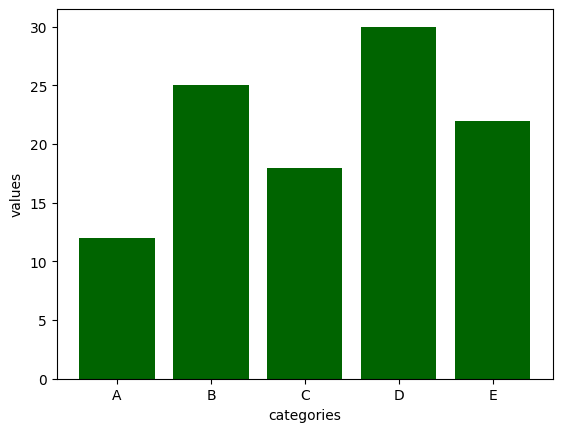

In [8]:
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

# 막대 그래프 생성
plt.bar(categories, values, color='darkgreen')

plt.xlabel("categories")
plt.ylabel("values")


# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- 누적형 막대 그래프를 생성하여, 두 개의 연도별 데이터를 각각 다른 색상으로 누적하여 표현

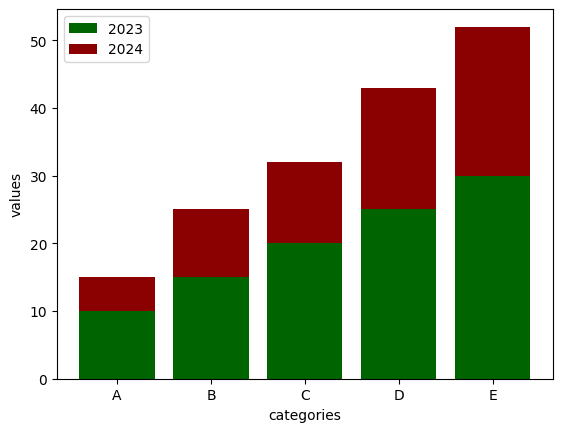

In [9]:
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

# 막대 위치 설정
x = np.arange(len(categories))

# 누적형 막대 그래프 생성
plt.bar(x, values_2023, color='darkgreen', label='2023')
plt.bar(x, values_2024, bottom=values_2023, color='darkred', label='2024')

# 축 설정
plt.xticks(x, categories) # x축 눈금(labels)을 categories 리스트로 설정
plt.xlabel("categories")
plt.ylabel('values')
plt.legend() # 범례 추가

# 그래프 표시
plt.show()

### 3. 3번 미니 퀘스트
- 한 기업의 부서별 연간 성과(2023년 vs 2024년)를 비교하는 그룹형 막대 그래프를 생성

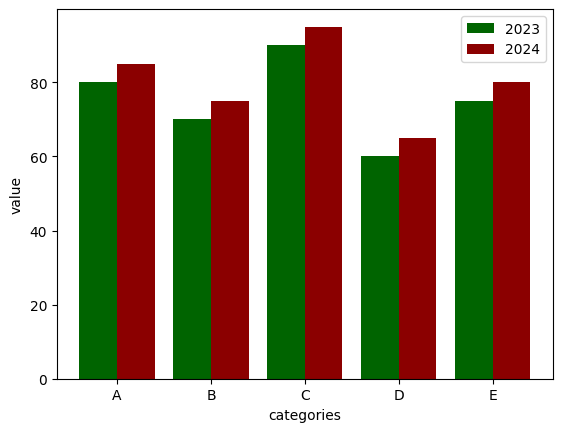

In [10]:
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

# 막대 너비 설정
bar_width = 0.4

# 막대 위치 설정
x = np.arange(len(categories))

# 그룹형 막대 그래프 생성
plt.bar(x - bar_width/2, performance_2023, bar_width, label='2023', color='darkgreen')
plt.bar(x + bar_width/2, performance_2024, bar_width, label='2024', color='darkred')

# 축 설정
plt.xticks(x, categories) # x축 눈금을 categories 리스트로 설정
plt.xlabel("categories")
plt.ylabel("value")
plt.legend() # 범례 추가

# 그래프 표시
plt.show()



---



## 히스토그램 (Histogram)

### 1. 1번 미니 퀘스트
- 정규 분포를 따르는 1000개의 데이터를 생성한 후, 구간을 15개로 설정한 히스토그램을 그리는 코드 작성

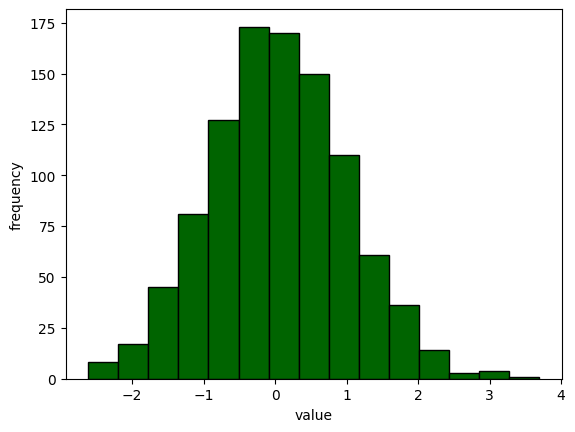

In [11]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000) # 평균 0, 표준편차 1인 정규 분포에서 1000개의 데이터 추출

# 기본 히스토그램 생성
plt.hist(data, bins=15, color='darkgreen', edgecolor='black')
plt.xlabel("value")
plt.ylabel("frequency")

# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- 두 개의 서로 다른 정규 분포를 따르는 데이터셋을 생성한 후, 두 히스토그램을 같은 그래프에서 겹쳐서 비교

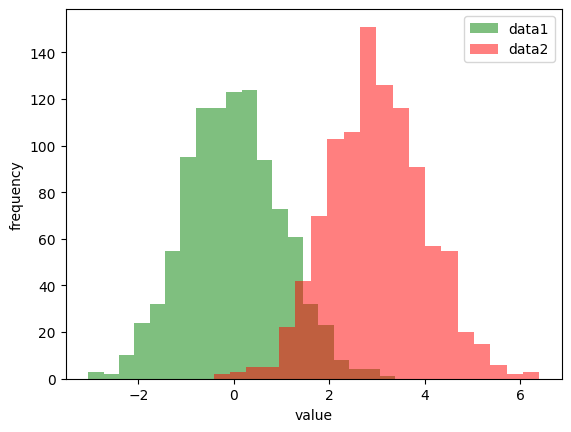

In [12]:
# 첫 번째 데이터셋 (평균 0, 표준편차 1)
data1 = np.random.randn(1000)

# 두 번째 데이터셋 (평균 3, 표준편차 1)
data2 = np.random.randn(1000) + 3

plt.hist(data1, bins=20, alpha=0.5, label='data1', color='green')
plt.hist(data2, bins=20, alpha=0.5, label='data2', color='red')

plt.xlabel("value")
plt.ylabel("frequency")
plt.legend()

# 그래프 표시
plt.show()

### 3. 3번 미니 퀘스트
- 한 데이터셋의 누적 히스토그램을 그린 후, X축과 Y축의 적절한 레이블을 설정

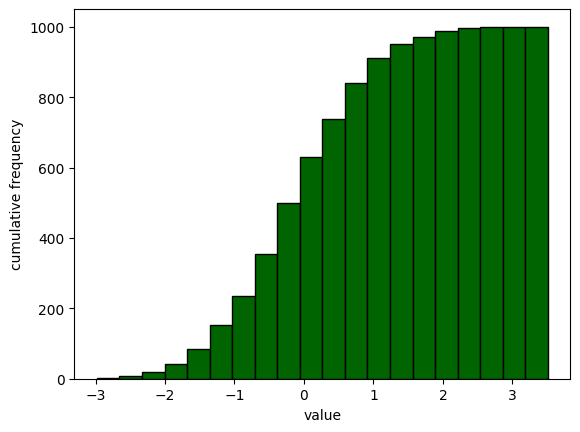

In [13]:
data = np.random.randn(1000)

# 누적 히스토그램
plt.hist(data, bins=20, cumulative=True, color='darkgreen', edgecolor='black')

plt.xlabel('value')
plt.ylabel('cumulative frequency')

plt.show()



---



## 산점도 (Scatter Plot)

### 1. 1번 미니 퀘스트
- 두 개의 리스트 x = [1, 2, 3, 4, 5], y = [3, 1, 4, 5, 2]를 사용하여 산점도를 그리고, X축과 Y축의 라벨 추가

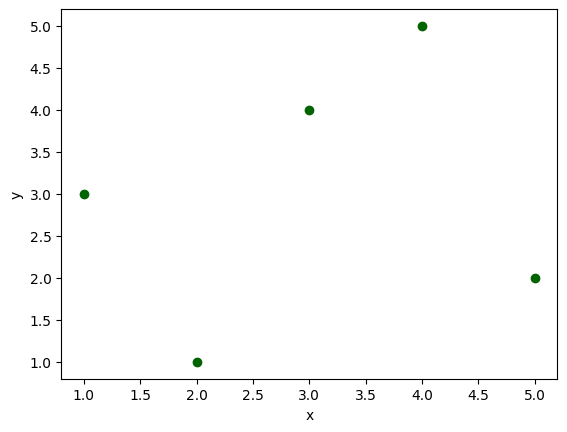

In [14]:
# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

# 산점도 생성
plt.scatter(x, y, color='darkgreen', marker='o')

plt.xlabel('x')
plt.ylabel('y')

# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- numpy를 활용하여 난수를 생성한 후, 산점도를 그리고 점의 색상과 투명도를 설정

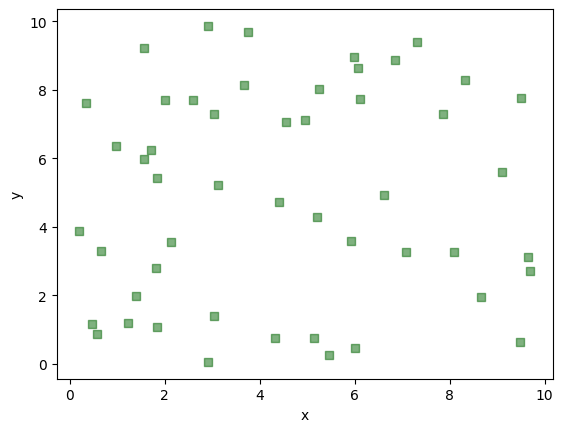

In [15]:
# 난수 데이터 생성
np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개

# 산점도 생성
# alpha: 점 투명도 설정
plt.scatter(x, y, color='darkgreen', marker='s', alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')

plt.show()

### 3. 3번 미니 퀘스트
- numpy를 활용하여 세 개의 그룹('A', 'B', 'C')에 속하는 데이터의 산점도를 서로 다른 색상으로 그리기

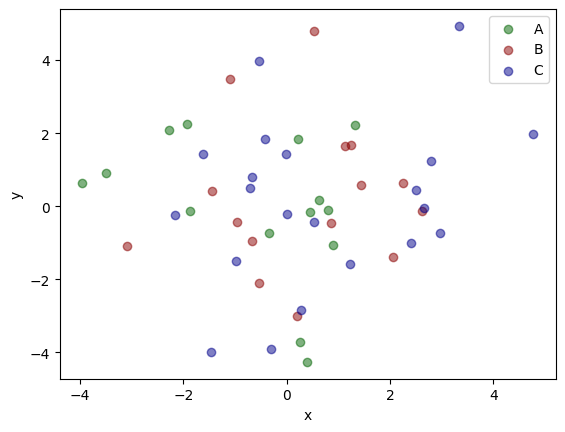

In [16]:
# 데이터 생성
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)

# 카테고리별 색상 지정
color = {'A': 'darkgreen', 'B': 'darkred', 'C': 'darkblue'}

# 산점도 생성
for cat in ['A', 'B', 'C']:
  plt.scatter(x[categories == cat], y[categories == cat], color=color[cat], label=cat, alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()



---



## 박스 플롯 (Box Plot)

### 1. 1번 미니 퀘스트
- 평균 0, 표준편차 1을 따르는 정규분포 난수 50개를 생성한 후, 해당 데이터를 이용해 기본 박스 플롯을 출력

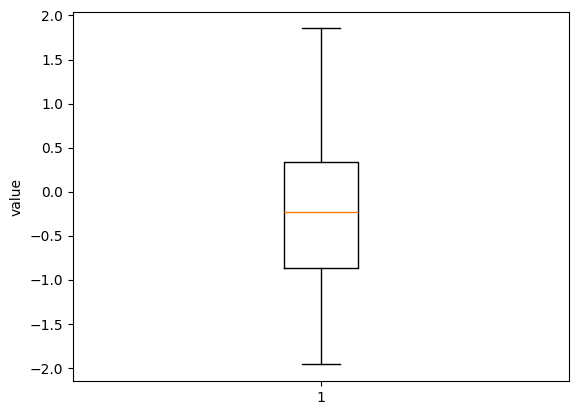

In [17]:
# 정규분포를 따르는 난수 50개 생성
np.random.seed(42) # 랜덤 시드 고정 (재현 가능성 보장)
data = np.random.randn(50)

# 박스 플롯 생성
plt.boxplot(data)
plt.ylabel('value')

plt.show()

### 2. 2번 미니 퀘스트
- 세 개의 그룹(Group A, Group B, Group C) 에 대해 각각 다른 평균을 가지는 데이터를 생성하고, 이를 이용해 다중 박스 플롯 그리기

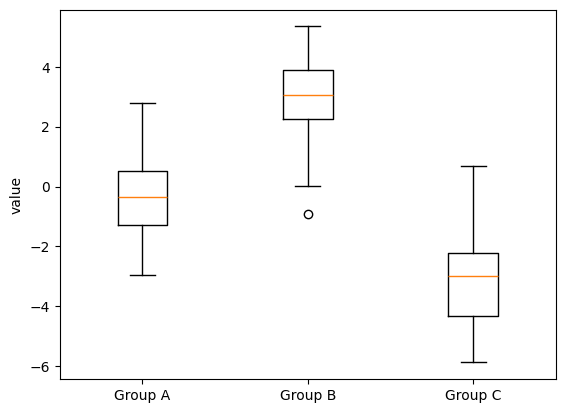

In [18]:
# 랜덤 데이터 생성 (각 그룹별 평균 다르게 설정)
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

# 여러 개의 박스 플롯 생성
plt.boxplot([group_a, group_b, group_c], tick_labels=['Group A', 'Group B', 'Group C'])
plt.ylabel('value')

plt.show()

### 3. 3번 미니 퀘스트
- 평균이 **서로 다른 두 개의 그룹(Group X, Group Y)** 을 비교하는 박스 플롯 그리기
(단, **이상값을 강조하고, 스타일을 커스터마이징**해야 함)

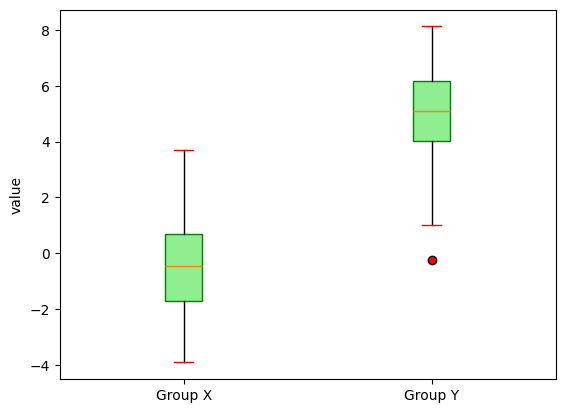

In [19]:
# 랜덤 데이터 생성 (두 그룹의 평균 다르게 설정)
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

# 서로 다른 그룹 비교
plt.boxplot([group_x, group_y],
            tick_labels=['Group X', 'Group Y'],
            patch_artist=True, # 박스 내부 색상 채우기
            boxprops=dict(facecolor="lightgreen", color="green"), # 박스 색상 설정
            whiskerprops=dict(color='black'), # 수염 색상 설정
            capprops=dict(color='red'), # 상/하한성 색상 설정
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6) # 이상값 강조
            )
plt.ylabel('value')



plt.show()



---



## 고급 다중 그래프 (Advanced Multiple Graphs)

### 1. 1번 미니 퀘스트
- `plt.subplots()`를 사용하여 2x1 형태의 서브플롯을 만들고, 첫 번째 서브플롯에는 `y = x^2`, 두 번째 서브플롯에는 `y = x^3`을 그리기

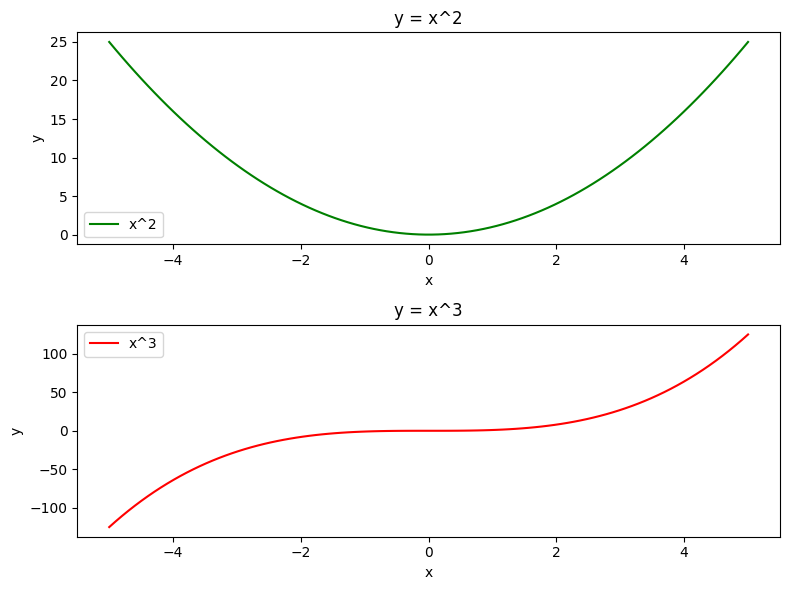

In [20]:
# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱

# 서브플롯 설정 (2행 1열)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# 첫 번째 서브플롯
axes[0].plot(x, y1, color='green', label='x^2')  # 첫 번째 서브플롯에 그래프 추가
axes[0].set_title("y = x^2")  # 제목 설정
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# 두 번째 서브플롯
axes[1].plot(x, y2, color='red', label='x^3')  # 두 번째 서브플롯에 그래프 추가
axes[1].set_title("y = x^3")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

# 전체 레이아웃 조정
plt.tight_layout()  # 그래프 간 간격 자동 조정

plt.show()

### 2. 2번 미니 퀘스트
- X축을 공유하는 1행 2열 형태의 서브플롯을 생성하고, 첫 번째 서브플롯에는 정규 분포를 따르는 난수의 히스토그램, 두 번째 서브플롯에는 균등 분포를 따르는 난수의 히스토그램 그리기

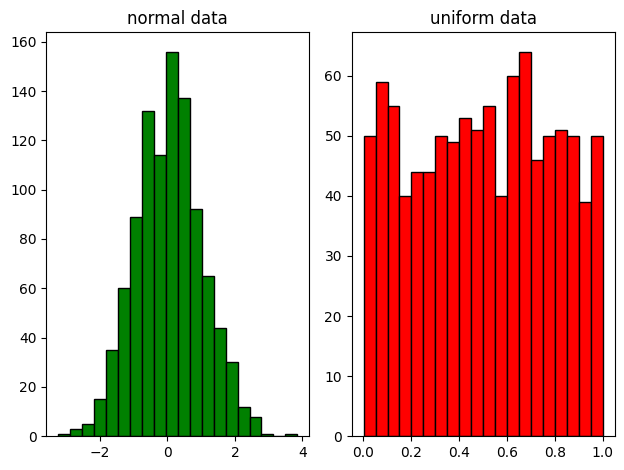

In [21]:
# 데이터 생성
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

# 서브플롯 설정 (1행 2열)
fig, axes = plt.subplots(nrows=1, ncols=2)

# 첫 번째 서브플롯
axes[0].hist(normal_data, bins=20, color='green', edgecolor='black')
axes[0].set_title("normal data")

# 두 번째 서브플롯
axes[1].hist(uniform_data, bins=20, color='red', edgecolor='black')
axes[1].set_title("uniform data")

plt.tight_layout()
plt.show()

### 3. 3번 미니 퀘스트
- `gridspec`을 사용하여 불규칙한 레이아웃의 서브플롯을 생성하고, 각각 선 그래프, 산점도, 막대 그래프, 히스토그램 그리기

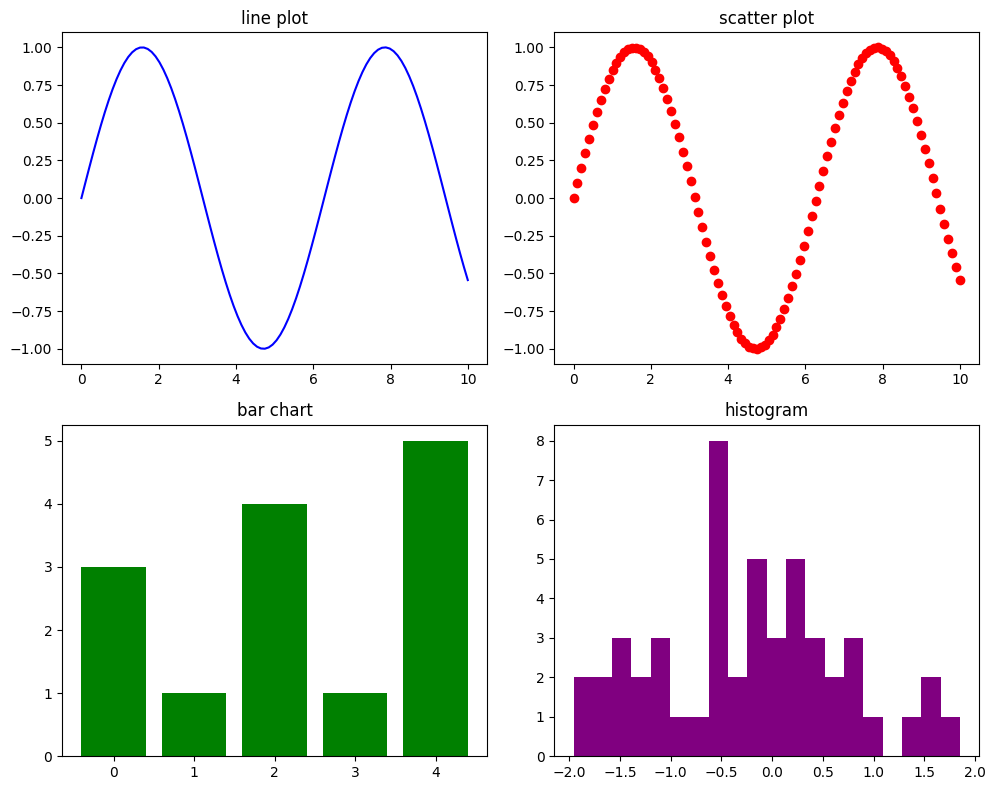

In [22]:
# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

# 2x2 서브플롯 생성, 크기는 10x8 인치
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 선 그래프
axes[0, 0].plot(x, y1, color='blue')
axes[0, 0].set_title("line plot")

# 산점도
axes[0, 1].scatter(x, y1, color='red')
axes[0, 1].set_title("scatter plot")

# 막대 그래프
axes[1, 0].bar(np.arange(5), [3, 1, 4, 1, 5], color='green')
axes[1, 0].set_title("bar chart")

# 히스토그램
axes[1, 1].hist(data, bins=20, color='purple')
axes[1, 1].set_title("histogram")

# 그래프 출력
plt.tight_layout()
plt.show()



---



## 벤 다이어그램 (Venn diagram)

### 1. 1번 미니 퀘스트
- 두 개의 과일 집합을 정의하고, 두 집합의 차집합(한 집합에만 존재하는 요소)을 출력

In [23]:
# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

print("A - B :", set_A - set_B) # A에만 존재하는 요소
print("B - A :", set_B - set_A) # B에만 존재하는 요소

A - B : {'체리', '사과'}
B - A : {'수박', '포도'}


### 2. 2번 미니 퀘스트
- 벤 다이어그램을 그리지 않고, 세 개의 집합을 비교하여 각 집합이 단독으로 가지는 요소 개수와 교집합 개수 계산

In [24]:
# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

# 각 집합만 단독으로 가지는 요소
only_A = set_A - set_B - set_C
only_B = set_B - set_A - set_C
only_C = set_C - set_A - set_B

# 교집합
A_B = set_A & set_B
A_C = set_A & set_C
B_C = set_B & set_C

# 세 집합 공통 교집합
A_B_C = set_A & set_B & set_C

print("A만:", only_A, "개수:", len(only_A))
print("B만:", only_B, "개수:", len(only_B))
print("C만:", only_C, "개수:", len(only_C), "\n")

print("A∩B:", A_B, "개수:", len(A_B))
print("A∩C:", A_C, "개수:", len(A_C))
print("B∩C:", B_C, "개수:", len(B_C), "\n")

print("A∩B∩C:", A_B_C, "개수:", len(A_B_C))

A만: {'체리', '사과'} 개수: 2
B만: {'포도'} 개수: 1
C만: {'오렌지', '딸기'} 개수: 2 

A∩B: {'망고', '바나나'} 개수: 2
A∩C: {'망고'} 개수: 1
B∩C: {'수박', '망고'} 개수: 2 

A∩B∩C: {'망고'} 개수: 1


### 3. 3번 미니 퀘스트
- 벤 다이어그램을 그리면서, 특정 조건을 만족하는 경우 색상을 다르게 지정하는 코드
  - **조건:** 두 개의 집합을 비교할 때, **교집합이 2개 이상이면 노란색, 그렇지 않으면 기본 색상**

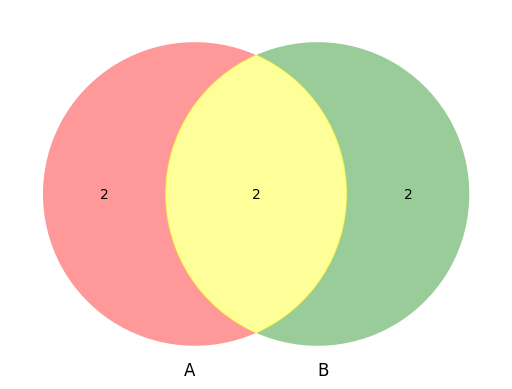

In [25]:
# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

# 교집합 개수 계산
intersection_count = len(set_A & set_B)

# 벤 다이어그램 생성
venn = venn2(
    [set_A, set_B],
    set_labels=('A', 'B')
)

# 조건에 따른 색상 변경
if intersection_count >= 2:
    venn.get_patch_by_id('11').set_color('yellow') # '11' -> A와 B 모두 포함되는 교집합 영역

plt.show()



---



## 범주형 데이터 (Categorical Data)

### 1. 1번 미니 퀘스트
- 샘플 데이터를 직접 생성한 후 Seaborn을 활용하여 막대 그래프(bar plot)를 생성

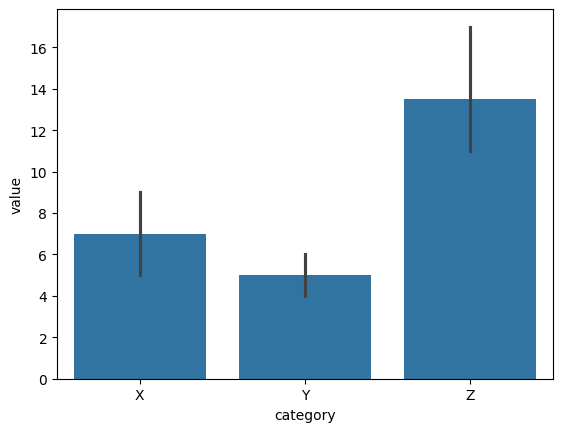

In [26]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "value": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})

# 기본 범주형 데이터 시각화 (막대 그래프)
sns.barplot(x="category", y="value", data=data)
plt.show()

### 2. 2번 미니 퀘스트
- Seaborn의 sns.boxplot()을 활용하여 범주형 데이터의 분포 시각화

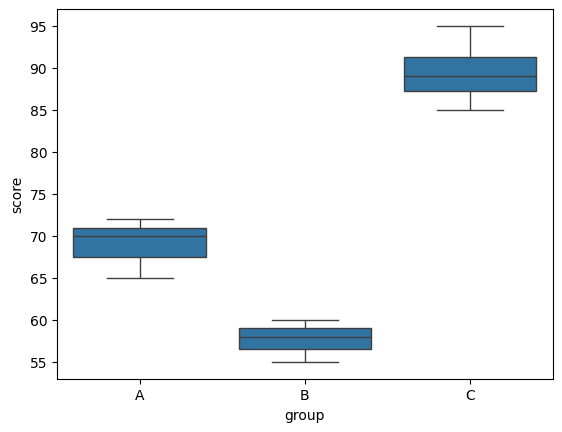

In [27]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})

# 범주형 데이터 분포 시각화 (박스 플롯)
sns.boxplot(x="group", y="score", data=data)
plt.show()

### 3. 3번 미니 퀘스트
- Seaborn의 sns.violinplot()과 sns.stripplot()을 함께 사용하여 범주형 데이터의 분포를 더욱 자세히 시각화

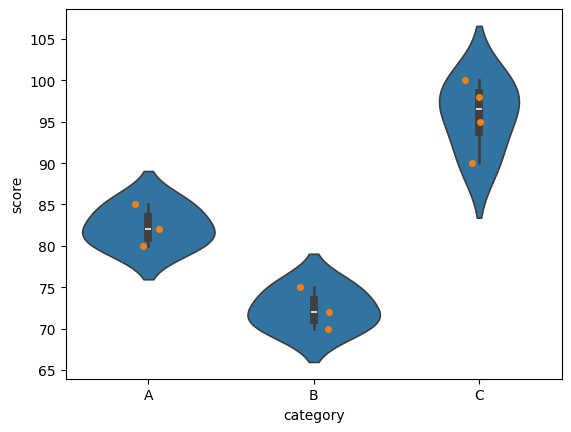

In [28]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})

# 범주형 데이터의 밀도 및 분포 시각화 (바이올린 플롯)
sns.violinplot(x="category", y="score", data=data)

# 범주형 데이터의 개별 데이터 포인트 시각화 (스트립 플롯)
#   jitter=True: 데이터 포인트가 겹쳐 보이지 않도록 위치를 조금씩 조정, 데이터 값 자체가 변하는 것은 X
sns.stripplot(x="category", y="score", data=data, jitter=True)

plt.show()



---



## 연속형 데이터 (Continuous Data)

### 1. 1번 미니 퀘스트
- 평균 0, 표준편차 1을 따르는 정규 분포 데이터를 500개 생성한 후, 히스토그램과 KDE를 함께 시각화

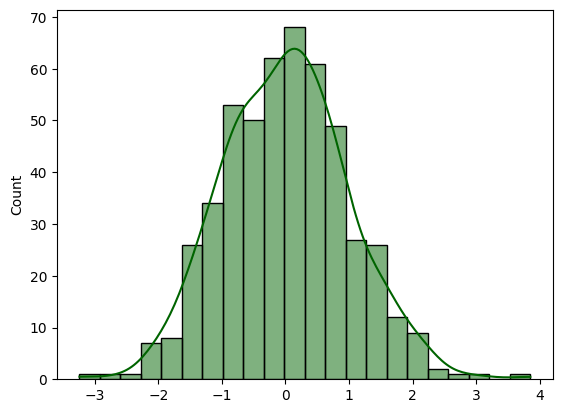

In [29]:
# 정규 분포를 따르는 데이터 생성
np.random.seed(42)
data = np.random.randn(500)

# 히스토그램과 KDE 시각화
sns.histplot(data, kde=True, color='darkgreen')

plt.show()

### 2. 2번 미니 퀘스트
- 0부터 20까지 균등한 간격으로 생성된 데이터를 사용하여, 사인 함수의 선 그래프 그리기

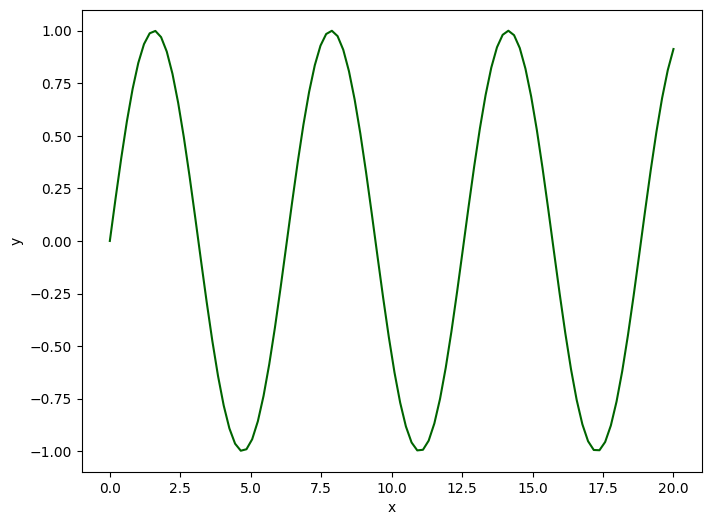

In [30]:
# X 값 생성 (0부터 20까지 100개의 균등한 값)
x = np.linspace(0, 20, 100)
y = np.sin(x)

# 선 그래프 생성
plt.figure(figsize=(8, 6))
sns.lineplot(x=x, y=y, color='darkgreen')

plt.xlabel("x")
plt.ylabel("y")

plt.show()

### 3. 3번 미니 퀘스트
- 랜덤한 100개의 연속형 데이터를 생성하여, 산점도와 회귀선을 포함한 그래프 그리기

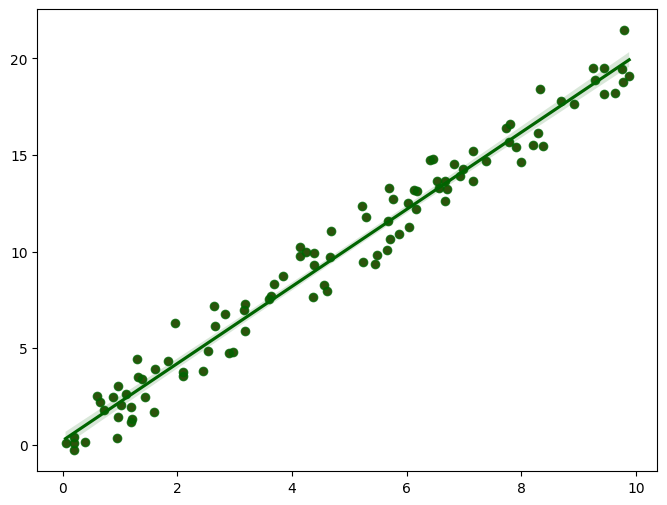

In [31]:
# 난수 생성 (재현 가능성 유지)
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이 난수
y = 2 * x + np.random.randn(100)  # x와 비례하는 관계, 약간의 변동 추가

plt.figure(figsize=(8, 6))

# 산점도 생성
sns.scatterplot(x=x, y=y, color='crimson')

# 회귀선 추가
sns.regplot(x=x, y=y, color='darkgreen')

plt.show()



---



## 관계 데이터 (Relational Data)

### 1. 1번 미니 퀘스트
- Seaborn의 `scatterplot`을 활용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계 시각화
- 단, `scatterplot`의 색상과 스타일을 다르게 설정하여 출력

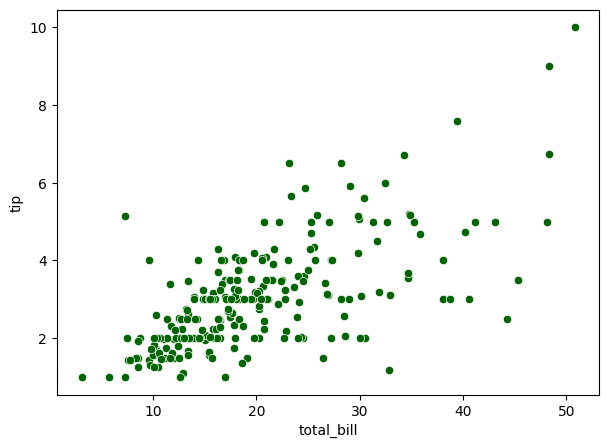

In [32]:
# 예제 데이터 로드 (Seaborn 내장 데이터셋: tips)
tips = sns.load_dataset("tips")

# 기본 산점도 (total_bill과 tip의 관계)
plt.figure(figsize=(7, 5))  # 그래프 크기 설정
sns.scatterplot(x="total_bill", y="tip", data=tips, color="darkgreen")

plt.show()

### 2. 2번 미니 퀘스트
- `sns.regplot`을 사용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계를 나타내는 회귀선 그래프를 그리고, 산점도의 투명도를 조정
- 단, 산점도에서 특정 성별(`sex`)만 필터링하여 표시

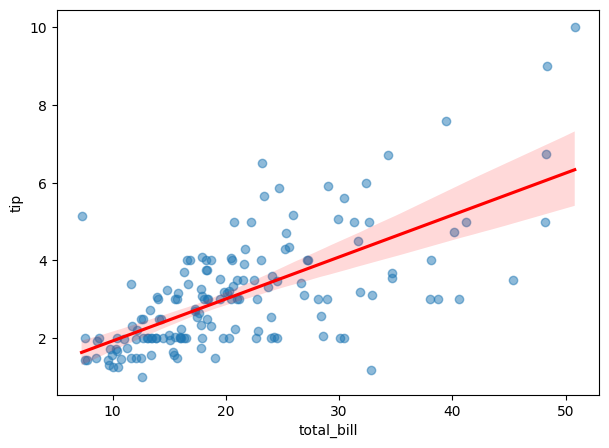

In [33]:
# 예제 데이터 로드
tips = sns.load_dataset("tips")

# 남성 데이터만 선택
male_tips = tips[tips['sex'] == 'Male']

plt.figure(figsize=(7, 5))

sns.regplot(x="total_bill", y="tip", data=male_tips, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.show()

### 3. 3번 미니 퀘스트
- `sns.pairplot`을 사용하여 다중 변수(`total_bill`, `tip`, `size`) 간의 관계를 성별(`sex`)과 요일(`day`)에 따라 시각화
- 단, 요일(`day`)에 따라 다른 색상 적용

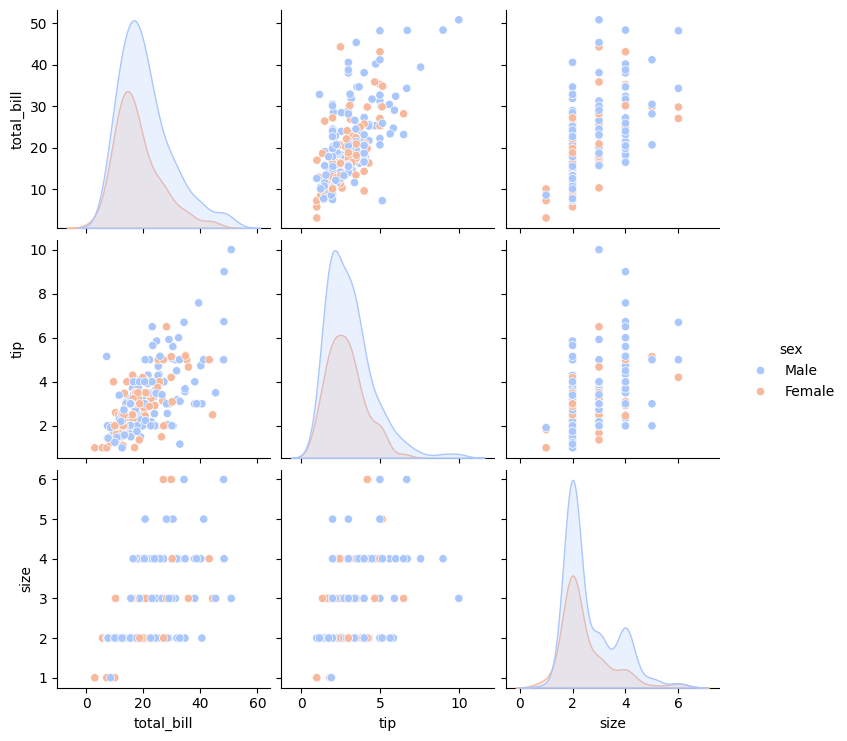

In [34]:
# 예제 데이터 로드
tips = sns.load_dataset("tips")

# 여러 변수 간의 관계를 한 번에 시각화
#   성별에 따라 색상 다르게 지정
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="sex", palette="coolwarm")

plt.show()

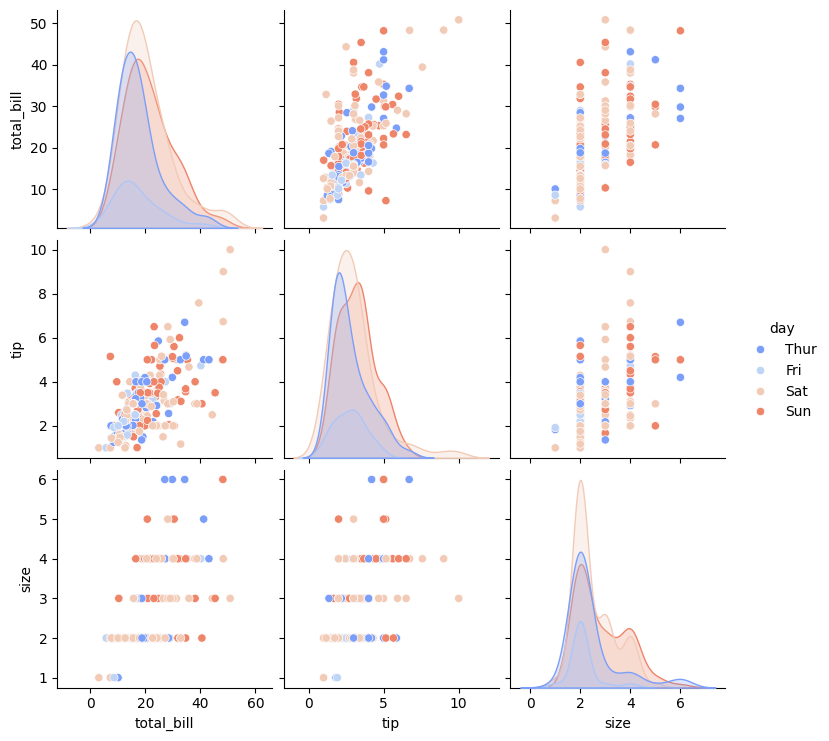

In [35]:
# 예제 데이터 로드
tips = sns.load_dataset("tips")

# 여러 변수 간의 관계를 한 번에 시각화
#   요일에 따라 색상 다르게 지정
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="day", palette="coolwarm")

plt.show()



---



## 시계열 데이터 (Time Series Data)

### 1. 1번 미니 퀘스트
- 100일간의 시계열 데이터를 생성하고, 이를 선 그래프로 시각화

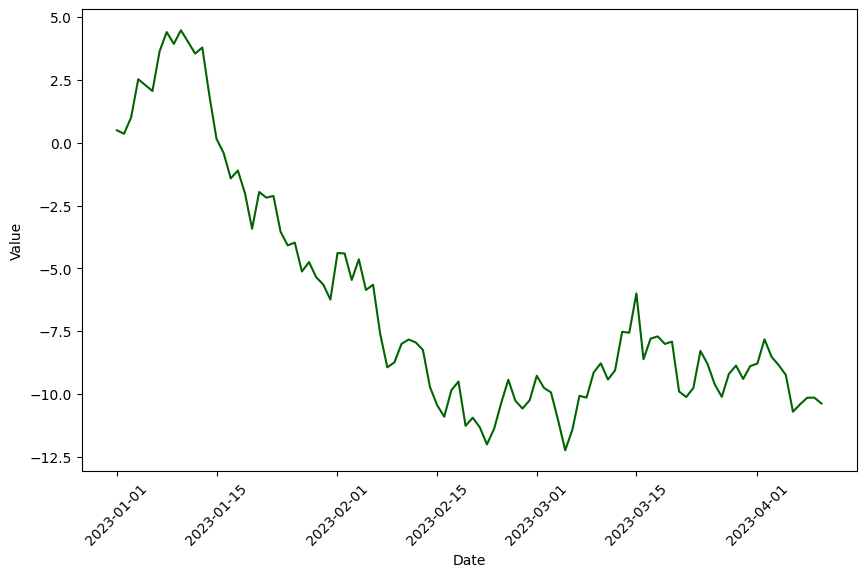

In [36]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
values = np.cumsum(np.random.randn(100))  # 랜덤 값의 누적합

# 데이터 프레임으로 변환
df = pd.DataFrame({"Date": date_range, "Value": values})

# 선 그래프 생성
plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="Value", data=df, color="darkgreen")

# X축 눈금 회전
plt.xticks(rotation=45)
plt.show()

### 2. 2번 미니 퀘스트
- 1번 퀘스트에서 생성한 데이터를 기반으로 7일 이동 평균을 계산
- 원본 데이터와 함께 그래프로 비교

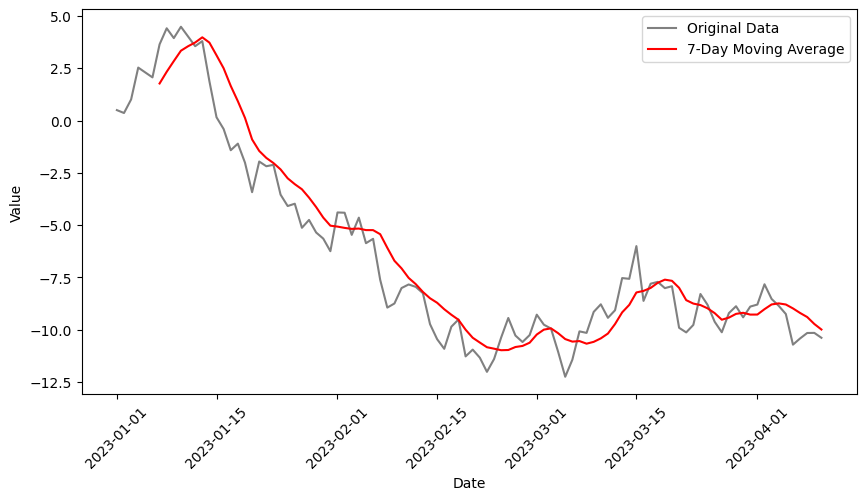

In [37]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

# 이동 평균(7일 평균) 계산
df["Moving_Avg"] = df["Value"].rolling(window=7).mean()  # 7일 이동 평균을 계산하여 새로운 컬럼 Moving_Avg에 저장

# 이동 평균 그래프 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="gray")  # 원본 데이터
sns.lineplot(x="Date", y="Moving_Avg", data=df, label="7-Day Moving Average", color="red")  # 이동 평균

plt.legend()
plt.xticks(rotation=45)

plt.show()

### 3. 3번 미니 퀘스트
- 1번 퀘스트에서 생성한 시계열 데이터에서 이상치를 탐지하고, 이상치만 강조하여 그래프에 표시
- 이상치는 사분위수 범위(IQR)를 이용해 판단

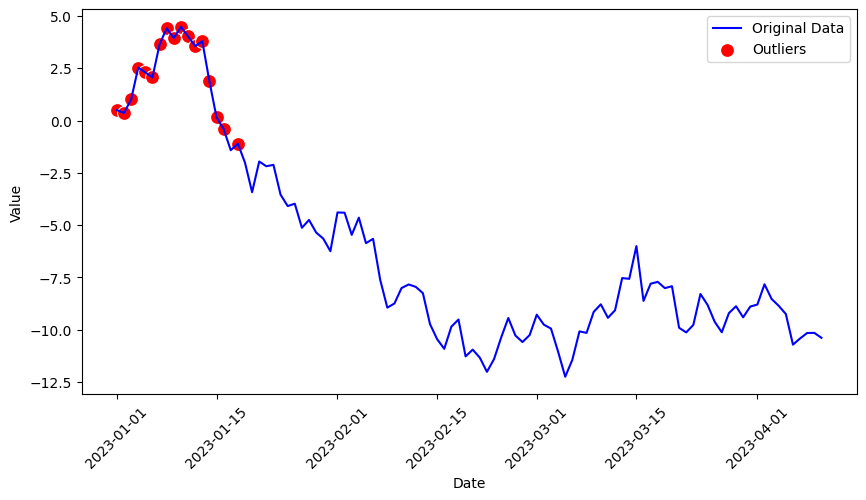

In [38]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

# 이상치 탐지를 위한 사분위 범위(IQR) 계산
Q1 = df["Value"].quantile(0.25)  # 1사분위수
Q3 = df["Value"].quantile(0.75)  # 3사분위수
IQR = Q3 - Q1  # IQR 계산

k = 0.5 # 이상치를 판별할 때 경계를 얼마나 넓게 잡을지 결정

lower_bound = Q1 - k * IQR  # 하한선
upper_bound = Q3 + k * IQR  # 상한선

# 이상치 여부 판별
df["Outlier"] = (df["Value"] < lower_bound) | (df["Value"] > upper_bound)  # 이상치 여부 (True/False)

# 이상치 데이터 필터링
outliers = df[df["Outlier"]]

# 이상치 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="blue")
sns.scatterplot(x="Date", y="Value", data=outliers, color="red", label="Outliers", s=100)  # 이상치 표시

plt.legend()
plt.xticks(rotation=45)

plt.show()



---



## 리샘플링 (Resampling)

### 1. 1번 미니 퀘스트
- `pandas`를 사용하여 3시간 간격의 시계열 데이터를 생성
- 하루 단위(`D`)로 평균을 구하는 다운샘플링 수행

In [39]:
# 3시간 간격의 시계열 데이터 생성 (2024년 1월 1일부터 5일까지)
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

# 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))  # 10~100 사이 랜덤 값
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 원본 데이터
print("[원본 데이터]")
print(df.head(), "\n")

# 하루 단위로 다운샘플링 (평균 값 사용)
df_daily = df.resample("D").mean()  # 'D'는 하루 단위 리샘플링

# 다운샘플링된 데이터 확인
print("\n[다운샘플링 데이터]")
print(df_daily.head())

[원본 데이터]
                     value
datetime                  
2024-01-01 00:00:00     18
2024-01-01 03:00:00     71
2024-01-01 06:00:00     46
2024-01-01 09:00:00     60
2024-01-01 12:00:00     53 


[다운샘플링 데이터]
             value
datetime          
2024-01-01  54.625
2024-01-02  58.375
2024-01-03  41.375
2024-01-04  50.000
2024-01-05  79.000


### 2. 2번 미니 퀘스트
- 3시간 간격으로 생성된 시계열 데이터에서 1시간 단위로 업샘플링
- 선형 보간(linear) 적용

In [40]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-03", freq="3h")

# 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))  # 10~100 사이 랜덤 값
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 원본 데이터
print("[원본 데이터]")
print(df.head(), "\n")

# 1시간 단위로 업샘플링 (보간 없이 NaN 유지)
df_hourly = df.resample("h").asfreq()  # 'h'는 1시간 단위 리샘플링을 의미

# 업샘플링된 데이터 확인
print("\n[업샘플링 데이터]")
print(df_daily.head(), "\n")

# 선형 보간 (linear interpolation)
df['보간값'] = df['value'].interpolate(method='linear')

print("\n[선형 보간]")
print(df.head())

[원본 데이터]
                     value
datetime                  
2024-01-01 00:00:00     41
2024-01-01 03:00:00     77
2024-01-01 06:00:00     64
2024-01-01 09:00:00     84
2024-01-01 12:00:00     65 


[업샘플링 데이터]
             value
datetime          
2024-01-01  54.625
2024-01-02  58.375
2024-01-03  41.375
2024-01-04  50.000
2024-01-05  79.000 


[선형 보간]
                     value  보간값
datetime                       
2024-01-01 00:00:00     41   41
2024-01-01 03:00:00     77   77
2024-01-01 06:00:00     64   64
2024-01-01 09:00:00     84   84
2024-01-01 12:00:00     65   65


### 3. 3번 미니 퀘스트
- 3시간 간격으로 생성된 시계열 데이터에서 하루 단위(D)로 다운샘플링 수행
- 각 날짜에 해당하는 최소(min) 값과 최대(max) 값 출력

In [41]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-07", freq="3h")

# 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))  # 10~100 사이 랜덤 값
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 원본 데이터
print("[원본 데이터]")
print(df.head())

# 하루 단위 최소값
daily_min = df.resample("D").min()

# 하루 단위 최대값
daily_max = df.resample("D").max()

# 다운샘플링된 데이터 확인
print("\n[일별 최소값]")
print(daily_min)

print("\n[일별 최대값]")
print(daily_max)

[원본 데이터]
                     value
datetime                  
2024-01-01 00:00:00     12
2024-01-01 03:00:00     29
2024-01-01 06:00:00     68
2024-01-01 09:00:00     45
2024-01-01 12:00:00     28

[일별 최소값]
            value
datetime         
2024-01-01     12
2024-01-02     10
2024-01-03     16
2024-01-04     10
2024-01-05     12
2024-01-06     33
2024-01-07     93

[일별 최대값]
            value
datetime         
2024-01-01     99
2024-01-02     91
2024-01-03     98
2024-01-04     99
2024-01-05     89
2024-01-06     84
2024-01-07     93




---



## 이동평균 (Moving Average)

### 1. 1번 미니 퀘스트
- 주어진 시계열 데이터에서 7일 단순 이동평균(SMA) 을 계산하여 새로운 컬럼 추가

In [42]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 7일 단위 단순 이동평균 적용
df['SMA'] = df['value'].rolling(window=7).mean()

# 상위 10개 데이터 출력
print(df.head(10).reset_index())

   index   datetime  value         SMA
0      0 2024-01-01    148         NaN
1      1 2024-01-02    138         NaN
2      2 2024-01-03    148         NaN
3      3 2024-01-04     74         NaN
4      4 2024-01-05    142         NaN
5      5 2024-01-06     67         NaN
6      6 2024-01-07    131  121.142857
7      7 2024-01-08    115  116.428571
8      8 2024-01-09    103  111.428571
9      9 2024-01-10     84  102.285714


### 2. 2번 미니 퀘스트
- 시계열 데이터에서 7일 지수 이동평균(EMA) 을 계산
- 기존 데이터와 비교하여 출력

In [43]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 7일 단위 단순 이동평균 적용
df['SMA'] = df['value'].rolling(window=7).mean()

# 7일 단위 지수 이동평균 적용
df['EMA'] = df['value'].ewm(span=7, adjust=False).mean()

# 상위 10개 데이터 출력
print(df.head(10).reset_index())

   index   datetime  value         SMA         EMA
0      0 2024-01-01     69         NaN   69.000000
1      1 2024-01-02     57         NaN   66.000000
2      2 2024-01-03     56         NaN   63.500000
3      3 2024-01-04    116         NaN   76.625000
4      4 2024-01-05     66         NaN   73.968750
5      5 2024-01-06     82         NaN   75.976562
6      6 2024-01-07     97   77.571429   81.232422
7      7 2024-01-08    125   85.571429   92.174316
8      8 2024-01-09    108   92.857143   96.130737
9      9 2024-01-10    135  104.142857  105.848053


### 3. 3번 미니 퀘스트
- 주어진 시계열 데이터에서 이동평균을 활용하여 변동성이 큰 날을 탐색
- 7일 단순 이동평균(SMA)과 비교하여 특정 일자의 값이 이동평균보다 ±20% 이상 차이가 나는 경우만 출력

In [44]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 7일 단위 단순 이동평균 적용
df['SMA'] = df['value'].rolling(window=7).mean()

# 이동평균 대비 편차율 계산
df["ratio"] = ((df["value"] - df["SMA"])/ df["SMA"])

# ±20% 이상 차이
volatile_days = df[abs(df["ratio"]) >= 0.20]

print(volatile_days[["datetime", "value", "SMA", "ratio"]])

     datetime  value         SMA     ratio
8  2024-01-09     68  104.142857 -0.347051
9  2024-01-10     53  100.714286 -0.473759
11 2024-01-12    113   91.857143  0.230171
13 2024-01-14     66   82.714286 -0.202073
15 2024-01-16    141   92.571429  0.523148
17 2024-01-18    142  104.571429  0.357923
19 2024-01-20     55   95.857143 -0.426230




---



## 금융 데이터 (Financial Data)

### 1. 1번 미니 퀘스트
- 샘플 금융 데이터프레임을 직접 생성
- 데이터의 기본 정보(행 개수, 열 개수, 데이터 타입 등)를 출력

In [45]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}

df = pd.DataFrame(data)

print(df)

# 행과 열 개수
print("\n행 개수:", df.shape[0])
print("열 개수:", df.shape[1])

# 데이터 타입
print("\n데이터 타입")
print(df.dtypes)

# 기본 정보
print("\n기본 정보")
print(df.info())

        Date  Open  High  Low  Close  Volume
0 2024-01-01   100   102   98    101    1000
1 2024-01-02   102   106  100    104    1200
2 2024-01-03   105   108  103    106    1500
3 2024-01-04   103   107  101    105    1300
4 2024-01-05   108   110  106    109    1600
5 2024-01-06   107   109  105    108    1400
6 2024-01-07   110   112  108    111    1700
7 2024-01-08   112   115  110    113    1800
8 2024-01-09   115   117  113    116    1900
9 2024-01-10   118   120  116    119    2000

행 개수: 10
열 개수: 6

데이터 타입
Date      datetime64[ns]
Open               int64
High               int64
Low                int64
Close              int64
Volume             int64
dtype: object

기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10 non-null     datetime64[ns]
 1   Open    10 non-null     int64         
 2   High    10 non-null     in

### 2. 2번 미니 퀘스트
- 주어진 `df` 데이터프레임에서 5일 이동평균(SMA)과 5일 지수 이동평균(EMA)을 계산

In [46]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}

df = pd.DataFrame(data)

# SMA
df['SMA'] = df['Close'].rolling(window=5).mean()

# EMA
df['EMA'] = df['Close'].ewm(span=5, adjust=False).mean()

print(df)

        Date  Close    SMA         EMA
0 2024-01-01    101    NaN  101.000000
1 2024-01-02    104    NaN  102.000000
2 2024-01-03    106    NaN  103.333333
3 2024-01-04    105    NaN  103.888889
4 2024-01-05    109  105.0  105.592593
5 2024-01-06    108  106.4  106.395062
6 2024-01-07    111  107.8  107.930041
7 2024-01-08    113  109.2  109.620027
8 2024-01-09    116  111.4  111.746685
9 2024-01-10    119  113.4  114.164457


### 3. 3번 미니 퀘스트
- `df` 데이터프레임에서 주간(7일) 단위로 종가(Close) 평균을 리샘플링
- 이를 바탕으로 주간 변동성(표준편차)을 계산

In [47]:
# 샘플 금융 데이터 생성 (30일치)
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))  # 100~200 사이의 랜덤 종가 생성

df = pd.DataFrame({'Date': date_rng, 'Close': close_prices})

# date 인덱스로 설정
df.set_index('Date', inplace=True)

# 원본 데이터
print("[원본 데이터]")
print(df.head(), "\n")

# 주간 평균 리샘플링
weekly_mean = df["Close"].resample("W").mean()

# 주간 변동성(표준편차)
weekly_volatility = df["Close"].resample("W").std()

print("주간 평균 종가")
print(weekly_mean)

print("\n주간 변동성")
print(weekly_volatility)

[원본 데이터]
                 Close
Date                  
2024-01-01  137.015870
2024-01-02  101.545662
2024-01-03  192.831856
2024-01-04  142.818415
2024-01-05  196.665482 

주간 평균 종가
Date
2024-01-07    164.648604
2024-01-14    150.143630
2024-01-21    151.810603
2024-01-28    164.001224
2024-02-04    183.859286
Freq: W-SUN, Name: Close, dtype: float64

주간 변동성
Date
2024-01-07    37.580450
2024-01-14    29.295798
2024-01-21    31.266680
2024-01-28    22.398749
2024-02-04     4.027604
Freq: W-SUN, Name: Close, dtype: float64


## 정규 분포 (Normal Distribution)

### 1. 1번 미니 퀘스트
- 평균 60, 표준 편차 15를 갖는 정규 분포에서 500개의 데이터를 생성
- 데이터의 기본 통계 정보(평균, 표준 편차, 최소값, 최대값)를 출력

In [48]:
# 평균 60, 표준 편차 15인 정규 분포에서 500개의 난수 생성
data = np.random.normal(loc=60, scale=15, size=500)

# 기본 통계 정보
print("평균:", np.mean(data))
print("표준편차:", np.std(data))
print("최소값:", np.min(data))
print("최대값:", np.max(data))

평균: 60.358530244927735
표준편차: 15.500031048439117
최소값: 18.885677333104475
최대값: 101.75666135233577


### 2. 2번 미니 퀘스트
- 평균 50, 표준 편차 10을 갖는 정규 분포에서 특정 값 x=65의 확률 밀도 함수(PDF) 값을 계산하고 출력

In [49]:
# 평균 50
mu = 50

# 표준편차 10
sigma = 10

# 특정 값
x = 65

pdf_value = stats.norm.pdf(x, loc=mu,scale=sigma)

print("PDF 값:", pdf_value)

PDF 값: 0.012951759566589175


### 3. 3번 미니 퀘스트
- 평균 70, 표준 편차 8을 갖는 정규 분포에서
  - (1) 특정 값 x=80 이하일 확률을 CDF로 계산
  - (2) 상위 5%에 해당하는 점수를 PPF로 계산하여 출력

In [50]:
# 평균
mu = 70

# 표준편차
sigma = 8

# 특정 점수
x = 80

# CDF
cdf_value = stats.norm.cdf(x, loc=mu, scale=sigma)

print("CDF 값(80 이하일 확률):", cdf_value)

# PPF (상위 5%)
ppf_value = stats.norm.ppf(0.95, loc=mu, scale=sigma)

print("PPF 값(상위 5% 기준 점수):", ppf_value)

CDF 값(80 이하일 확률): 0.8943502263331446
PPF 값(상위 5% 기준 점수): 83.15882901561177




---



## 기술 통계 (Descriptive Statistics)

### 1. 1번 미니 퀘스트
- 주어진 데이터에서 평균과 중앙값의 차이를 계산

In [51]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

# 평균
mean_value = df["value"].mean()

# 중앙값
median_value = df["value"].median()

# 차이
difference = mean_value - median_value

print("평균:", mean_value)
print("중앙값:", median_value)
print("평균 - 중앙값:", difference)

평균: 48.96153482605907
중앙값: 48.73043708220287
평균 - 중앙값: 0.2310977438562034


### 2. 2번 미니 퀘스트
- 데이터에서 이상값(Outlier)을 찾아 제거
- 원래 데이터와 이상값 제거 후 데이터의 평균을 비교

- 이상값은 IQR(사분위 범위)를 사용하여 탐지

In [52]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

# 원본 평균
original_mean = df["value"].mean()

# Q1, Q3
Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 경계
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
filtered_df = df[(df["value"] >= lower_bound) & (df["value"] <= upper_bound)]

# 이상치 제거 후 평균
filtered_mean = filtered_df["value"].mean()

print("원본 평균:", original_mean)
print("이상치 제거 후 평균:", filtered_mean)

print("원본 데이터 개수:", len(df))
print("제거 후 데이터 개수:", len(filtered_df))

원본 평균: 48.96153482605907
이상치 제거 후 평균: 49.215665996432364
원본 데이터 개수: 100
제거 후 데이터 개수: 99


### 3. 3번 미니 퀘스트
- 데이터의 왜도(Skewness)와 첨도(Kurtosis)를 계산하여 데이터의 분포 특성을 분석

In [53]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

# 왜도
skewness = df["value"].skew()

# 첨도
kurtosis = df["value"].kurtosis()

print("왜도:", skewness)
print("첨도:", kurtosis)

왜도: -0.1779481426259557
첨도: -0.10097745347286446




---



## 가설 검정 (Hypothesis Testing)

### 1. 1번 미니 퀘스트
- **단일 표본 t-검정(One-Sample t-test)** 을 수행하여 샘플 데이터의 평균이 특정 값과 유의미한 차이가 있는지 검정
  - (평균 `50`, 표준 편차 `5`를 따르는 정규 분포에서 30개의 데이터를 생성하고, 해당 데이터가 평균 `52`와 차이가 있는지 확인)

In [54]:
# 샘플 데이터 생성
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)  # 평균 50, 표준편차 5인 데이터 30개 생성

# 단일 표본 t-검정
t_stat, p_value = stats.ttest_1samp(sample_data, popmean=52)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# 유의수준
alpha = 0.05

if p_value < alpha:
    print("\n[귀무가설 기각] 샘플 평균은 52와 유의미한 차이가 있음")
else:
    print("\n[귀무가설 채택] 샘플 평균은 52와 유의미한 차이 없음")

t-statistic: -3.5793224601074907
p-value: 0.0012367258279248469

[귀무가설 기각] 샘플 평균은 52와 유의미한 차이가 있음


### 2. 2번 미니 퀘스트
- 카이제곱 검정(Chi-Square Test) 을 수행하여 관측된 데이터와 기대값이 유의미한 차이가 있는지 확인

In [55]:
# 관측된 데이터 (Observed)
observed = np.array([50, 60, 90])

# 기대값 (Expected)
expected = np.array([66, 66, 66]) * (observed.sum() / np.sum([66, 66, 66]))

# 카이제곱 검정
chi_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print("chi-square statistic:", chi_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\n[귀무가설 기각] 관측값과 기대값 사이에 유의미한 차이 있음")
else:
    print("\n[귀무가설 채택] 관측값과 기대값 사이에 유의미한 차이 없음")

chi-square statistic: 13.0
p-value: 0.0015034391929775717

[귀무가설 기각] 관측값과 기대값 사이에 유의미한 차이 있음


### 3. 3번 미니 퀘스트
- 분산 분석(ANOVA, Analysis of Variance) 을 수행하여 여러 그룹의 평균이 서로 다른지 검정

In [56]:
# 샘플 데이터 생성
np.random.seed(42)
group_1 = np.random.normal(loc=50, scale=10, size=30)  # 평균 50, 표준편차 10
group_2 = np.random.normal(loc=55, scale=10, size=30)  # 평균 55, 표준편차 10
group_3 = np.random.normal(loc=60, scale=10, size=30)  # 평균 60, 표준편차 10

# 일원분산분석
f_stat, p_value = stats.f_oneway(group_1, group_2, group_3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\n[귀무가설 기각] 세 그룹 중 적어도 하나의 평균은 다름")
else:
    print("\n[귀무가설 채택] 세 그룹 평균에 유의미한 차이 없음")

F-statistic: 12.209525517972809
p-value: 2.1200748140507065e-05

[귀무가설 기각] 세 그룹 중 적어도 하나의 평균은 다름




---



## 통계적 시각화 (Statistical Visualization)

### 1. 1번 미니 퀘스트
- NumPy를 사용하여 평균 70, 표준편차 20을 따르는 정규 분포 데이터 1000개 생성
- Matplotlib을 활용하여 박스플롯 그리기

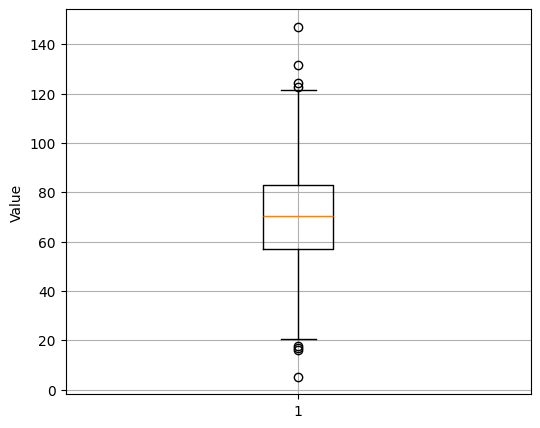

In [57]:
# 데이터 생성 (평균=70, 표준편차=20인 정규 분포 데이터 1000개)
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

# 박스플롯 그리기
plt.figure(figsize=(6, 5))
plt.boxplot(data)
plt.ylabel("Value")

plt.grid(True)
plt.show()

### 2. 2번 미니 퀘스트
- 평균이 각각 55와 60이고, 표준편차가 8인 두 개의 그룹(A, B) 데이터 생성
- 두 그룹의 데이터 분포를 Seaborn을 활용하여 KDE(커널 밀도 함수)와 함께 히스토그램으로 시각화
- 두 그룹 간 평균 차이가 유의미한지 t-검정을 수행

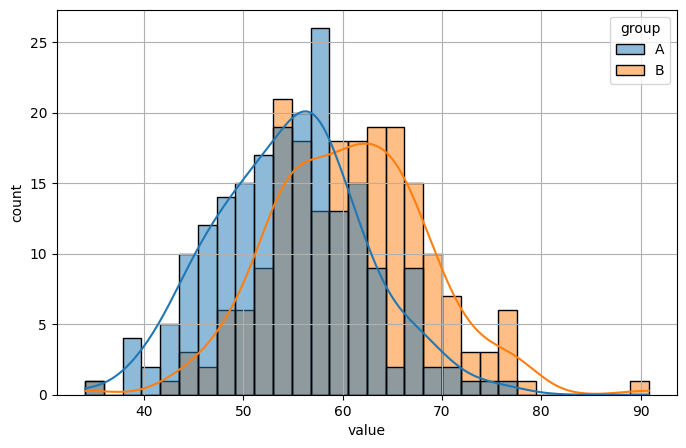

group A 평균: 54.67383227862332
group B 평균: 60.68694549519101

t-statistic: -7.834368710058932
p-value: 4.335288307834178e-14

[귀무가설 기각] 두 그룹의 평균 차이 유의미


In [58]:
# 데이터 생성
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)  # 평균 55, 표준편차 8
group_B = np.random.normal(loc=60, scale=8, size=200)  # 평균 60, 표준편차 8

# DataFrame 생성
df = pd.DataFrame({
    "value": np.concatenate([group_A, group_B]),
    "group": ["A"] * len(group_A) + ["B"] * len(group_B)
})

# 히스토그램 + KDE
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="value", hue="group", kde=True, bins=30, alpha=0.5)


plt.xlabel("value")
plt.ylabel("count")

plt.grid(True)
plt.show()

# 독립표본 t-검정
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("group A 평균:", np.mean(group_A))
print("group B 평균:", np.mean(group_B))

print("\nt-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\n[귀무가설 기각] 두 그룹의 평균 차이 유의미")
else:
    print("\n[귀무가설 채택] 두 그룹의 평균 차이는 유의미하지 않음")

### 3. 3번 미니 퀘스트
- 광고 A를 본 500명 중 120명이 클릭하였고, 광고 B를 본 500명 중 150명이 데이터 클릭
- 이 데이터를 바탕으로 카이제곱 검정을 수행하여 광고 A와 B의 클릭률 차이가 유의미한지 분석
- Seaborn의 barplot을 사용하여 클릭률을 비교하는 그래프

          Ad_A  Ad_B
Click      120   150
No Click   380   350

chi-square statistic: 4.266869609335362
p-value: 0.03886246168579381
degrees of freedom: 1
expected values:
[[135. 135.]
 [365. 365.]]

[귀무가설 기각] 광고 A와 B의 클릭률 차이는 유의미합


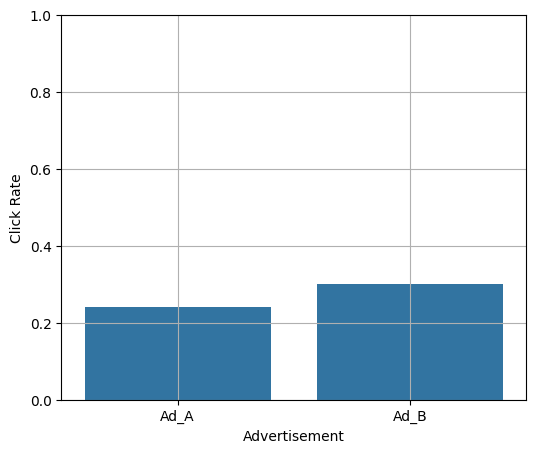

     Ad  Click Rate
0  Ad_A        0.24
1  Ad_B        0.30


In [59]:
# 데이터 생성 (광고 A와 B의 클릭 여부)
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],  # 광고 A 클릭(120명) vs 미클릭(380명)
    "Ad_B": [150, 350]   # 광고 B 클릭(150명) vs 미클릭(350명)
}, index=["Click", "No Click"])

print(observed_data)

# 카이제곱 검정
chi2, p_value, dof, expected = stats.chi2_contingency(observed_data)

print("\nchi-square statistic:", chi2)
print("p-value:", p_value)
print("degrees of freedom:", dof)
print("expected values:")
print(expected)

alpha = 0.05

if p_value < alpha:
    print("\n[귀무가설 기각] 광고 A와 B의 클릭률 차이는 유의미합")
else:
    print("\n[귀무가설 채택] 광고 A와 B의 클릭률 차이는 유의미하지 않음")

# 클릭률 계산
click_rates = pd.DataFrame({
    "Ad": ["Ad_A", "Ad_B"],
    "Click Rate": [
        observed_data.loc["Click", "Ad_A"] / observed_data["Ad_A"].sum(),
        observed_data.loc["Click", "Ad_B"] / observed_data["Ad_B"].sum()
    ]
})

# 클릭률 barplot
plt.figure(figsize=(6, 5))
sns.barplot(data=click_rates, x="Ad", y="Click Rate")


plt.xlabel("Advertisement")
plt.ylabel("Click Rate")
plt.ylim(0, 1)

plt.grid(True)
plt.show()

print(click_rates)